In [ ]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
#Loading the dataset
fake = pd.read_csv(r'D:\Projects\DataScience\FakeNewsDetection\Fake.csv')
real = pd.read_csv(r'D:\Projects\DataScience\FakeNewsDetection\True.csv')

fake["label"] = 0 
real["label"] = 1

df = pd.concat([fake, real], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [4]:
df.info()
df['label'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 1.7 MB


label
0    23481
1    21417
Name: count, dtype: int64

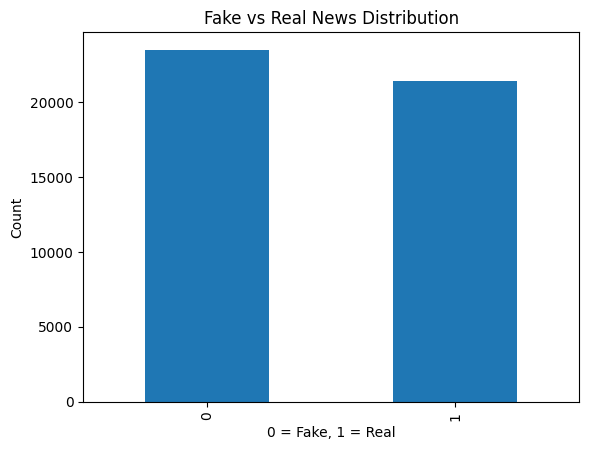

In [6]:
plt.figure()
df['label'].value_counts().plot(kind='bar')
plt.title('Fake vs Real News Distribution')
plt.xlabel("0 = Fake, 1 = Real")
plt.ylabel('Count')
plt.show()

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

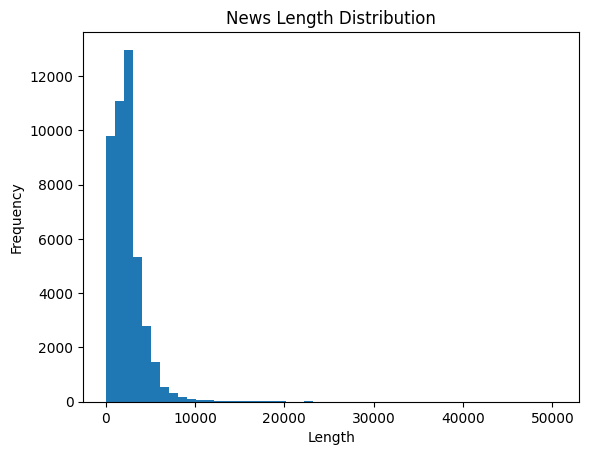

In [10]:
df['length'] = df['clean_text'].apply(len)

plt.figure()
plt.hist(df['length'], bins=50)
plt.title('News Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

In [11]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [13]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

In [14]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("classification Report", classification_report(y_test, y_pred))

Accuracy:  0.9861915367483296
classification Report               precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



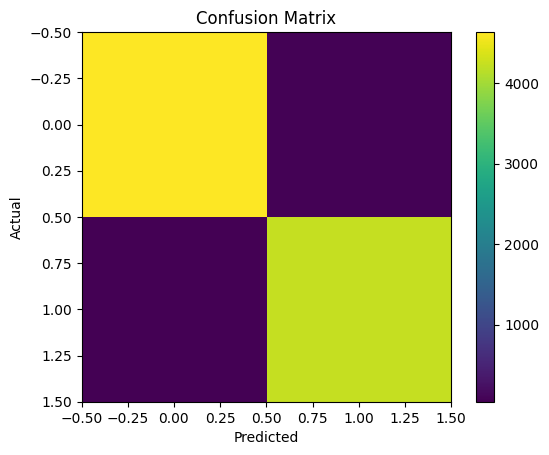

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [17]:
def predict_news(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    return "Real News" if prediction == 1 else "Fake News"

In [20]:
user_text = input("Enter news text: ")

print("\nInput:", user_text)
print("Prediction:", predict_news(user_text))


Input: This shocking secret cure for cancer has been hidden by doctors for years!
Prediction: Fake News
